In [31]:
from pathlib import Path
from collections import Counter
import math
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'src' / 'placefields').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'src' / 'placefields').is_dir():
    raise RuntimeError('Could not find repository root containing src/placefields')

sys.path.insert(0, str(repo_root / 'src'))

from placefields import (
    BayesianDecoderConfig,
    RatemapConfig,
    build_ratemap_from_trials,
    build_regular_xbin,
    build_trial_info_from_traj,
    canonical_condition_name,
    condition_family_name,
    cue_zone_layout_for_condition,
    decode_bayesian_position_from_trials,
    decode_condway,
    ifreq_swap,
    load_traj_condition_names,
    matlab_1b_to_python_0b,
    normalize_x_to_100,
    position_balanced_bayesian_decoding_accuracy,
    bayesian_decoding_result_to_frame,
    local_decoding_probability_by_actual_bin,
    cue_zone_layouts_by_condway,
)
from placefields.interim_io import (
    find_pairs,
    load_allcel_spikes,
    load_traj_fields,
    stitch_trial_series,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo_root

WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass')

In [32]:
#Mass,  width error and correlation. 
# We need speed threshold, neuron threshold, cell type. Don't group between conditions.
# Session selection
INTERIM_ROOT = repo_root / 'data' / 'interim'
SESSION_ID = None          # e.g. 'VS100_2024-11-03_14-40-11'; None means random
MIN_NEURONS = 0           # Set to 0 if useful_sessions_decoding.csv should be the only session filter
USE_ONLY_USEFUL_SESSIONS = True
USEFUL_SESSIONS_CSV = repo_root / 'results' / 'tables' / 'useful_sessions_decoding.csv'
RANDOM_SEED = 17
TRY_RANDOM_SESSIONS = 13    # If a random eligible session has no decodable windows, try another

# Decoder parameters
SPIKE_FREQ_HZ = 25_000.0
BEHAVIOR_FREQ_HZ = 1_000.0
TAU_S = 0.350
BIN_SIZE_CM = 3.0
MIN_SPEED = 2.0            # Set to None to disable speed filtering
DECODE_GROUPBY = 'condway'  # condway = condition + direction separated; condition/global are controls
GROUP_CONDITION_FAMILIES = False  # True pools PO/PO2/PO3/PONM and POM/POMB before decoding
SMOOTH_SIGMA_BINS = 3
XBIN_REM = 0
MIN_VALID_WINDOW_FRACTION = 0.5
RATE_FLOOR_HZ = 1e-12
NORMALIZE_X_TO_100 = False
TRAIN_ALL_LAPS = True  # True = train on all laps in the same condition-direction; False = leave-one-lap-out

# Cell selection. 'PYR+SMINTER' = all pyramidal cells + interneurons with SM=True in at least one SSI condition.
CELL_SELECTION_MODE = 'PYR+SMINTER'  # 'all' | 'PYR+SMINTER'
SSI_PROCESSED_ROOT = repo_root / 'data' / 'processed'

# Set to an integer for a faster draft run on large sessions; None uses all active cells.
MAX_CELLS = None

# Plot controls
TRACE_CONDWAY = 1       # None uses all condition-directions; set an int like 1 or 2 for one condway
TRACE_INCLUDE_PAIRED_DIRECTION = True  # If TRACE_CONDWAY is set, also show the matching W/B partner
MAX_TRACE_WINDOWS = None     # None uses all selected decoded windows; paired directions are balanced below
BEHAVIOR_TRACE_STRIDE = 5    # Plot every nth raw behavior sample for the actual-position trace
TRACE_TIME_MODE = 'selected_trials'  # 'selected_trials' removes between-condition gaps; 'session' keeps absolute time
TRACE_TRIAL_GAP_S = 0.0      # Gap between selected trials when TRACE_TIME_MODE='selected_trials'
TRACE_FLIP_BACKWARD_FOR_DISPLAY = 'auto'  # 'auto' flips B on the plot if raw B laps increase in stored coordinates
TRACE_SHOW_CONDITION_BLOCKS = True  # Draw vertical separators and labels for condition blocks on the trace
MAX_POSTERIOR_WINDOWS = 250
MIN_BEST_LAP_WINDOWS = 10  # Minimum decoded windows required when selecting the lowest-error lap
N_RANDOM_HEATMAP_CELLS = 5
NEURON_HEATMAP_SEED = 13
ROW_NORMALIZE_NEURON_HEATMAPS = True

In [33]:
def count_recorded_cells(allcel_path):
    _, _, id_cel = load_allcel_spikes(allcel_path)
    return int(np.asarray(id_cel).size), ''


def parse_bool_series(values):
    values = pd.Series(values)
    if values.dtype == bool:
        return values.fillna(False)
    return values.map(lambda value: str(value).strip().lower() in {'true', '1', 'yes'})


def processed_ssi_classification_path(session_id):
    mouse = str(session_id).split('_', 1)[0]
    return SSI_PROCESSED_ROOT / mouse / 'ssi' / str(session_id) / 'ssi_classification.csv'


def pyr_plus_sm_interneuron_cell_ids(session_id, available_cell_ids):
    ssi_path = processed_ssi_classification_path(session_id)
    if not ssi_path.exists():
        raise FileNotFoundError(f'Missing processed SSI classification for {session_id}: {ssi_path}')
    d = pd.read_csv(ssi_path)
    type_col = 'cell_type' if 'cell_type' in d.columns else 'pred_type' if 'pred_type' in d.columns else None
    if type_col is None:
        raise KeyError(f'{ssi_path} must contain cell_type or pred_type for PYR+SMINTER selection')
    if 'SM' not in d.columns:
        raise KeyError(f'{ssi_path} is missing SM')
    d = d.copy()
    d['cell_id'] = pd.to_numeric(d['cell_id'], errors='coerce')
    d = d.dropna(subset=['cell_id']).copy()
    d['cell_id'] = d['cell_id'].astype(np.int64)
    available = np.asarray(available_cell_ids, dtype=np.int64).ravel()
    d = d[np.isin(d['cell_id'], available)]
    d['cell_type_norm'] = d[type_col].astype(str).str.strip().str.lower()
    d['SM_bool'] = parse_bool_series(d['SM'])
    pyr_ids = set(d.loc[d['cell_type_norm'] == 'pyramidal', 'cell_id'].astype(np.int64))
    sm_inter_ids = set(d.loc[(d['cell_type_norm'] == 'interneuron') & d['SM_bool'], 'cell_id'].astype(np.int64))
    selected = np.asarray(sorted(pyr_ids.union(sm_inter_ids)), dtype=np.int64)
    meta = {
        'ssi_classification_csv': ssi_path,
        'n_pyramidal_selected': int(len(pyr_ids)),
        'n_sm_interneuron_selected': int(len(sm_inter_ids)),
    }
    return selected, meta


def select_decoder_cell_ids(session_id, available_cell_ids):
    mode = str(CELL_SELECTION_MODE).strip().lower()
    available = np.asarray(available_cell_ids, dtype=np.int64).ravel()
    if mode in {'all', ''}:
        selected = available.copy()
        meta = {'cell_selection_mode': 'all'}
    elif mode in {'pyr+sminter', 'pyr+sm_inter', 'pyr_sm_inter', 'pyr+sm-inter'}:
        selected, meta = pyr_plus_sm_interneuron_cell_ids(session_id, available)
        meta['cell_selection_mode'] = 'PYR+SMINTER'
    else:
        raise ValueError("CELL_SELECTION_MODE must be 'all' or 'PYR+SMINTER'")
    if selected.size == 0:
        raise ValueError(f'No cells selected for {session_id} with CELL_SELECTION_MODE={CELL_SELECTION_MODE!r}')
    return selected, meta


def load_useful_session_ids(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing useful-session CSV: {path}')
    table = pd.read_csv(path)
    if 'session_id' not in table.columns:
        raise KeyError(f'{path} must contain a session_id column')

    table = table.copy()
    table['session_id'] = table['session_id'].astype('string').str.strip()
    table = table[table['session_id'].notna() & (table['session_id'] != '')]
    table = table.drop_duplicates('session_id', keep='first')
    if table.empty:
        raise ValueError(f'{path} does not contain any non-empty session_id values')
    return set(table['session_id']), table


def eligible_pairs(interim_root, min_neurons, allowed_session_ids=None):
    rows = []
    skipped = []
    allowed = None
    if allowed_session_ids is not None:
        allowed = {str(session_id).strip() for session_id in allowed_session_ids if str(session_id).strip()}

    for session_id, allcel_path, traj_path in find_pairs(interim_root, set()):
        session_id = str(session_id).strip()
        if allowed is not None and session_id not in allowed:
            continue
        try:
            n_cells, reason = count_recorded_cells(allcel_path)
        except Exception as exc:
            n_cells, reason = None, str(exc)
        if n_cells is None:
            skipped.append((session_id, allcel_path, reason))
            continue
        if n_cells >= int(min_neurons):
            rows.append((session_id, allcel_path, traj_path, n_cells))
    if skipped:
        print(f'Skipped {len(skipped)} allcel files that do not match the expected decoder schema.')
        for session_id, allcel_path, reason in skipped[:5]:
            print(f'  {session_id}: {allcel_path.name} ({reason})')
        if len(skipped) > 5:
            print(f'  ... {len(skipped) - 5} more')
    return rows


def build_condition_name_map(traj_path):
    try:
        cond_raw, names_raw = load_traj_condition_names(traj_path)
    except Exception:
        return {}

    out = {}
    for cond in np.unique(cond_raw.astype(np.int64, copy=False)):
        names = [
            canonical_condition_name(name)
            for name in names_raw[cond_raw == cond].tolist()
            if canonical_condition_name(name)
        ]
        if not names:
            continue
        counts = Counter(names)
        out[int(cond)] = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
    return out


def condition_label_for_condway(condway, condition_name_map):
    base_condition_1b, direction = decode_condway(int(condway))
    name = condition_name_map.get(int(base_condition_1b), f'cond{base_condition_1b}')
    return f'{name} {direction}'


def paired_direction_condway(condway):
    condway = int(condway)
    return condway + 1 if condway % 2 else condway - 1


def condition_name_for_condway(condway, condition_name_map):
    base_condition_1b, _ = decode_condway(int(condway))
    return condition_name_map.get(int(base_condition_1b), f'cond{base_condition_1b}')


def cue_layout_for_condway(condway, condition_name_map):
    name = condition_name_for_condway(condway, condition_name_map)
    return cue_zone_layout_for_condition(name, condition_family=condition_family_name(name))


def draw_cue_zones_y(ax, layout, *, show_labels=False, style='spans'):
    if style not in {'spans', 'axis_marker'}:
        raise ValueError("style must be 'spans' or 'axis_marker'")
    for start, end in layout.poor_spans:
        if style == 'spans':
            ax.axhspan(start, end, color='tab:blue', alpha=0.035, lw=0, zorder=0)
        if show_labels:
            ax.text(0.005, 0.5 * (start + end), 'poor', transform=ax.get_yaxis_transform(), va='center', ha='left', color='tab:blue', fontsize=8, alpha=0.8)
    for start, end in layout.rich_spans:
        if style == 'spans':
            ax.axhspan(start, end, color='gold', alpha=0.14, lw=0, zorder=0)
        else:
            ax.plot([-0.012, -0.012], [start, end], transform=ax.get_yaxis_transform(), color='goldenrod', lw=6, solid_capstyle='butt', clip_on=False, zorder=5)
        if show_labels:
            ax.text(0.005, 0.5 * (start + end), 'rich', transform=ax.get_yaxis_transform(), va='center', ha='left', color='goldenrod', fontsize=8, alpha=0.9)
    if style == 'spans':
        for start, end in layout.excluded_spans:
            ax.axhspan(start, end, color='0.7', alpha=0.08, lw=0, zorder=0)
    for center in layout.object_centers:
        ax.axhline(center, color='black', ls='--', lw=1.1, alpha=0.75, zorder=1)


def draw_cue_zones_x(ax, layout, *, show_labels=False):
    for start, end in layout.poor_spans:
        ax.axvspan(start, end, color='tab:blue', alpha=0.035, lw=0, zorder=2)
        if show_labels:
            ax.text(0.5 * (start + end), 0.98, 'poor', transform=ax.get_xaxis_transform(), va='top', ha='center', color='tab:blue', fontsize=8, alpha=0.8)
    for start, end in layout.rich_spans:
        ax.axvspan(start, end, color='gold', alpha=0.14, lw=0, zorder=2)
        if show_labels:
            ax.text(0.5 * (start + end), 0.98, 'rich', transform=ax.get_xaxis_transform(), va='top', ha='center', color='goldenrod', fontsize=8, alpha=0.9)
    for start, end in layout.excluded_spans:
        ax.axvspan(start, end, color='0.7', alpha=0.08, lw=0, zorder=2)
    for center in layout.object_centers:
        ax.axvline(center, color='black', ls='--', lw=1.1, alpha=0.75, zorder=3)


def run_decoder_for_pair(session_id, allcel_path, traj_path):
    itime_25k, id_spk, id_cel = load_allcel_spikes(allcel_path)
    cond, wb, start, stop, vr_list, speed_list = load_traj_fields(traj_path)
    condition_name_map = build_condition_name_map(traj_path)

    x = stitch_trial_series(start, stop, vr_list)
    if NORMALIZE_X_TO_100:
        x = normalize_x_to_100(x)

    if speed_list is None and MIN_SPEED is not None:
        raise ValueError('No XSpeed/Speed field; set MIN_SPEED=None to decode without speed filtering')
    speed = stitch_trial_series(start, stop, speed_list) if speed_list is not None else None

    trials = build_trial_info_from_traj(
        cond=cond,
        wb=wb,
        start_1b=start,
        stop_1b=stop,
        n_samples=int(x.size),
    )
    spike_idx_1b = ifreq_swap(itime_25k, SPIKE_FREQ_HZ, BEHAVIOR_FREQ_HZ)
    spike_idx_0b = matlab_1b_to_python_0b(spike_idx_1b)

    cell_ids, cell_selection_meta = select_decoder_cell_ids(session_id, id_cel)
    if MAX_CELLS is not None:
        cell_ids = cell_ids[: int(MAX_CELLS)]
        cell_selection_meta['max_cells'] = int(MAX_CELLS)
        cell_selection_meta['n_cells_after_max_cells'] = int(cell_ids.size)

    xbin_edges = build_regular_xbin(x, BIN_SIZE_CM)
    cfg = BayesianDecoderConfig(
        freq_hz=BEHAVIOR_FREQ_HZ,
        tau_s=TAU_S,
        bin_size_cm=BIN_SIZE_CM,
        min_speed=MIN_SPEED,
        smooth_sigma_bins=SMOOTH_SIGMA_BINS,
        xbin_rem=XBIN_REM,
        min_valid_window_fraction=MIN_VALID_WINDOW_FRACTION,
        rate_floor_hz=RATE_FLOOR_HZ,
        decode_groupby=DECODE_GROUPBY,
        group_condition_families=GROUP_CONDITION_FAMILIES,
        train_all_laps=TRAIN_ALL_LAPS,
    )
    result = decode_bayesian_position_from_trials(
        position_x=x,
        spike_indices_0b=spike_idx_0b,
        spike_cell_ids=id_spk,
        cell_ids=cell_ids,
        trials=trials,
        xbin_edges=xbin_edges,
        cfg=cfg,
        speed=speed,
        condition_names_by_base=condition_name_map,
    )
    context = {
        'session_id': session_id,
        'allcel_path': allcel_path,
        'traj_path': traj_path,
        'position_x': x,
        'speed': speed,
        'trials': trials,
        'spike_idx_0b': spike_idx_0b,
        'id_spk': id_spk,
        'id_cel': id_cel,
        'xbin_edges_full': xbin_edges,
        'condition_name_map': condition_name_map,
        'cell_selection_meta': cell_selection_meta,
        'n_cells_available': int(np.asarray(id_cel).size),
        'n_cells_requested': int(cell_ids.size),
    }
    return result, context


def result_to_frame(result):
    return pd.DataFrame(
        {
            'trial_index': result.trial_index_w,
            'condway': result.condway_w,
            'base_condition': [decode_condway(condway)[0] for condway in result.condway_w],
            'direction': [decode_condway(condway)[1] for condway in result.condway_w],
            'window_start': result.window_start_w,
            'window_stop': result.window_stop_w,
            'window_mid_s': 0.5 * (result.window_start_w + result.window_stop_w) / BEHAVIOR_FREQ_HZ,
            'actual_x': result.actual_x_w,
            'decoded_x': result.decoded_x_w,
            'actual_bin': result.actual_bin_w,
            'decoded_bin': result.decoded_bin_w,
            'error_cm': result.error_cm_w,
            'prob_actual': result.prob_actual_w,
            'n_spikes': result.n_spikes_w,
            'n_train_laps': result.n_train_laps_w,
            'train_group': result.train_group_w,
            'train_group_label': result.train_group_label_w.astype(str),
        }
    )


def behavior_trace_frame_for_condways(context, condways, stride=5, trial_gap_s=0.0):
    x = np.asarray(context['position_x'], dtype=float)
    trials = context['trials']
    condways = {int(condway) for condway in condways}
    stride = max(1, int(stride))
    trial_gap_s = max(0.0, float(trial_gap_s))
    condition_name_map = context.get('condition_name_map', {})
    frames = []
    selected_offset_s = 0.0
    for trial in trials:
        if int(trial.condway) not in condways:
            continue
        start = max(0, int(trial.start_idx_0b))
        stop = min(int(x.size), int(trial.stop_idx_0b_exclusive))
        if stop <= start:
            continue
        sample_index = np.arange(start, stop, stride, dtype=np.int64)
        position = x[sample_index]
        keep = np.isfinite(position)
        sample_index = sample_index[keep]
        position = position[keep]
        if sample_index.size == 0:
            continue
        base_condition, direction = decode_condway(int(trial.condway))
        condition_name = condition_name_map.get(int(base_condition), f'cond{base_condition}')
        trial_time_s = (sample_index - start) / BEHAVIOR_FREQ_HZ
        frames.append(
            pd.DataFrame(
                {
                    'trial_index': int(trial.trial_index),
                    'condway': int(trial.condway),
                    'base_condition': int(base_condition),
                    'condition_name': condition_name,
                    'condition_label': f'{condition_name} {direction}',
                    'direction': direction,
                    'trial_start_index': start,
                    'trial_stop_index': stop,
                    'selected_offset_s': selected_offset_s,
                    'sample_index': sample_index,
                    'session_time_s': sample_index / BEHAVIOR_FREQ_HZ,
                    'trial_time_s': trial_time_s,
                    'selected_time_s': selected_offset_s + trial_time_s,
                    'position_x': position,
                }
            )
        )
        selected_offset_s += (stop - start) / BEHAVIOR_FREQ_HZ + trial_gap_s
    columns = [
        'trial_index', 'condway', 'base_condition', 'condition_name', 'condition_label',
        'direction', 'trial_start_index', 'trial_stop_index',
        'selected_offset_s', 'sample_index', 'session_time_s', 'trial_time_s',
        'selected_time_s', 'position_x',
    ]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=columns)


def resolve_backward_common_axis_flip(deltas, setting='auto'):
    if isinstance(setting, str):
        normalized = setting.strip().lower()
        if normalized in {'false', 'no', '0'}:
            return False
        if normalized in {'true', 'yes', '1'}:
            return True
        if normalized != 'auto':
            raise ValueError("TRACE_FLIP_BACKWARD_FOR_DISPLAY must be 'auto', True, or False")
        delta_values = np.asarray(deltas, dtype=float)
        delta_values = delta_values[np.isfinite(delta_values)]
        return bool(delta_values.size and np.nanmedian(delta_values) > 0)
    return bool(setting)


def should_flip_backward_for_display(behavior_df, setting='auto'):
    b_df = behavior_df[behavior_df['direction'] == 'B']
    deltas = b_df.groupby('trial_index', sort=False)['position_x'].agg(lambda values: values.iloc[-1] - values.iloc[0])
    return resolve_backward_common_axis_flip(deltas.to_numpy(dtype=float), setting)


def should_flip_backward_for_context(context, setting='auto'):
    x = np.asarray(context['position_x'], dtype=float)
    deltas = []
    for trial in context['trials']:
        _, direction = decode_condway(int(trial.condway))
        if direction != 'B':
            continue
        start = max(0, int(trial.start_idx_0b))
        stop = min(int(x.size), int(trial.stop_idx_0b_exclusive))
        position = x[start:stop]
        position = position[np.isfinite(position)]
        if position.size >= 2:
            deltas.append(float(position[-1] - position[0]))
    return resolve_backward_common_axis_flip(deltas, setting)


def positions_on_common_axis(values, directions, *, x_min, x_max, flip_backward):
    out = np.asarray(values, dtype=float).copy()
    if not flip_backward:
        return out
    direction_values = np.asarray(directions).astype(str)
    if direction_values.ndim == 0:
        if str(direction_values.item()).upper() == 'B':
            out = float(x_min) + float(x_max) - out
        return out
    is_backward = np.char.upper(direction_values) == 'B'
    if is_backward.shape != out.shape:
        is_backward = np.broadcast_to(is_backward, out.shape)
    out[is_backward] = float(x_min) + float(x_max) - out[is_backward]
    return out


def spatial_array_on_common_axis(values, direction, *, flip_backward, axis=-1):
    out = np.asarray(values)
    if flip_backward and str(direction).upper() == 'B':
        return np.flip(out, axis=axis)
    return out


def condition_blocks_for_trace(behavior_df):
    if behavior_df.empty:
        return pd.DataFrame(columns=['condition_name', 'start_s', 'stop_s', 'n_laps'])
    laps = (
        behavior_df.sort_values(['plot_time_s', 'sample_index'])
        .groupby('trial_index', sort=False)
        .agg(
            condition_name=('condition_name', 'first'),
            start_s=('plot_time_s', 'min'),
            stop_s=('plot_time_s', 'max'),
        )
        .reset_index()
    )
    blocks = []
    current = None
    for row in laps.itertuples(index=False):
        if current is None or row.condition_name != current['condition_name']:
            if current is not None:
                blocks.append(current)
            current = {
                'condition_name': row.condition_name,
                'start_s': float(row.start_s),
                'stop_s': float(row.stop_s),
                'n_laps': 1,
            }
        else:
            current['stop_s'] = float(row.stop_s)
            current['n_laps'] += 1
    if current is not None:
        blocks.append(current)
    return pd.DataFrame(blocks)


def draw_condition_blocks_on_trace(ax, blocks):
    if blocks.empty:
        return
    x0, x1 = ax.get_xlim()
    min_label_width = 0.035 * max(1e-9, x1 - x0)
    for i, block in blocks.reset_index(drop=True).iterrows():
        start_s = float(block['start_s'])
        stop_s = float(block['stop_s'])
        if i > 0:
            ax.axvline(start_s, color='0.45', ls=':', lw=1.1, alpha=0.85, zorder=6)
        if stop_s - start_s >= min_label_width:
            ax.text(
                0.5 * (start_s + stop_s),
                0.985,
                str(block['condition_name']),
                transform=ax.get_xaxis_transform(),
                ha='center',
                va='top',
                fontsize=8,
                color='0.25',
                zorder=7,
            )

We check whether the session we are looking into has an acceptable number of neurons.

In [34]:
useful_session_ids = None
useful_sessions_df = pd.DataFrame()
session_filter_label = 'all paired sessions'

if USE_ONLY_USEFUL_SESSIONS:
    useful_session_ids, useful_sessions_df = load_useful_session_ids(USEFUL_SESSIONS_CSV)
    useful_sessions_csv_label = USEFUL_SESSIONS_CSV.relative_to(repo_root)
    session_filter_label = f'useful sessions from {useful_sessions_csv_label}'
    print(f'Loaded {len(useful_session_ids)} session IDs from {useful_sessions_csv_label}')

pairs = eligible_pairs(
    INTERIM_ROOT,
    MIN_NEURONS,
    allowed_session_ids=useful_session_ids,
)

if USE_ONLY_USEFUL_SESSIONS:
    useful_order = {
        session_id: index
        for index, session_id in enumerate(useful_sessions_df['session_id'].astype(str))
    }
    pairs = sorted(pairs, key=lambda pair: useful_order.get(str(pair[0]), len(useful_order)))
    paired_session_ids = {str(pair[0]) for pair in pairs}
    omitted_session_ids = [
        session_id
        for session_id in useful_sessions_df['session_id'].astype(str)
        if session_id not in paired_session_ids
    ]
    if omitted_session_ids:
        print(
            f'{len(omitted_session_ids)} useful sessions are missing from paired data '
            f'or below MIN_NEURONS={MIN_NEURONS}.'
        )
        preview = ', '.join(omitted_session_ids[:8])
        suffix = ' ...' if len(omitted_session_ids) > 8 else ''
        print(f'  {preview}{suffix}')

if not pairs:
    raise RuntimeError(
        f'No paired sessions with at least {MIN_NEURONS} cells under {INTERIM_ROOT} '
        f'after applying filter: {session_filter_label}'
    )

print(
    f'Eligible paired sessions for decoding: {len(pairs)} '
    f'({session_filter_label}; MIN_NEURONS={MIN_NEURONS})'
)

if SESSION_ID:
    candidates = [pair for pair in pairs if pair[0] == SESSION_ID]
    if not candidates:
        n_found = 0
        for sid, allcel_path, _, _ in find_pairs(INTERIM_ROOT, set()):
            if sid == SESSION_ID:
                n_found, _ = count_recorded_cells(allcel_path)
                print(f'Found {n_found} cells for session {SESSION_ID}')
                n_found = 0 if n_found is None else int(n_found)
                break
        useful_note = ''
        if USE_ONLY_USEFUL_SESSIONS and SESSION_ID not in useful_session_ids:
            useful_note = f' {SESSION_ID} is not listed in {USEFUL_SESSIONS_CSV.relative_to(repo_root)}.'
        raise RuntimeError(
            f'SESSION_ID not found among filtered sessions with >= {MIN_NEURONS} cells: '
            f'{SESSION_ID} (found {n_found}).{useful_note}'
        )
else:
    rng = np.random.default_rng(RANDOM_SEED)
    candidates = [pairs[index] for index in rng.permutation(len(pairs))]
    print(f'Random candidate order seeded with RANDOM_SEED={RANDOM_SEED}; first session: {candidates[0][0]}')


Loaded 18 session IDs from results\tables\useful_sessions_decoding.csv
Eligible paired sessions for decoding: 18 (useful sessions from results\tables\useful_sessions_decoding.csv; MIN_NEURONS=0)
Random candidate order seeded with RANDOM_SEED=17; first session: VS116_2025-02-23_18-33-27


In [35]:
session_id, allcel_path, traj_path, n_cells = candidates[0]
result, context = run_decoder_for_pair(session_id, allcel_path, traj_path)
context["cue_layouts_by_condway"] = cue_zone_layouts_by_condway(
    result.condway_w,
    context["condition_name_map"],
    xbin_edges=result.xbin_edges,
)
decode_df = bayesian_decoding_result_to_frame(
    result,
    freq_hz=BEHAVIOR_FREQ_HZ,
    condition_names_by_base=context["condition_name_map"],
)

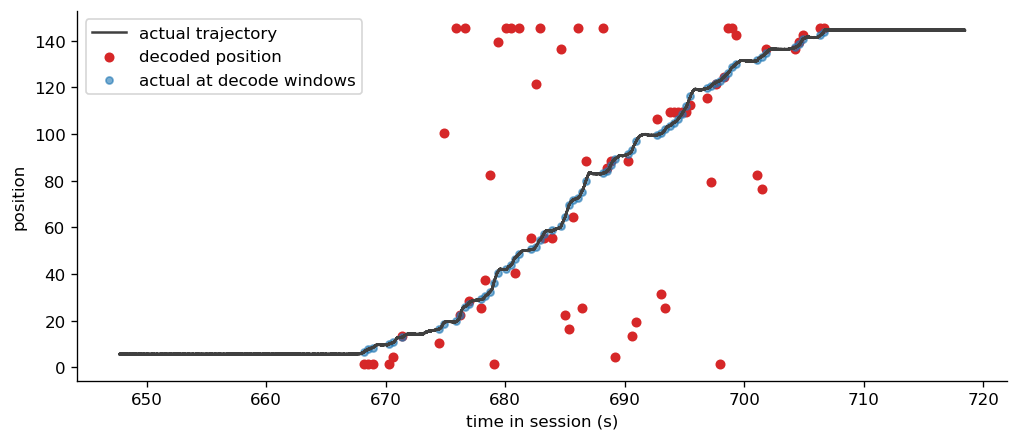

In [36]:
trial_id = 6  # or choose one from decode_df["trial_index"].unique()
trial = context["trials"][trial_id]
start = trial.start_idx_0b
stop = trial.stop_idx_0b_exclusive
start_s = start / BEHAVIOR_FREQ_HZ
stop_s = stop / BEHAVIOR_FREQ_HZ

x_trial = context["position_x"][start:stop]
t_trial = np.arange(start, stop) / BEHAVIOR_FREQ_HZ
trial_decode_df = decode_df[decode_df["trial_index"] == trial_id].copy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(t_trial, x_trial, color="0.25", lw=1.5, label="actual trajectory")

ax.scatter(
    trial_decode_df["window_mid_s"],
    trial_decode_df["decoded_x"],
    s=25,
    color="tab:red",
    label="decoded position",
)

ax.scatter(
    trial_decode_df["window_mid_s"],
    trial_decode_df["actual_x"],
    s=18,
    color="tab:blue",
    alpha=0.6,
    label="actual at decode windows",
)

ax.set_xlabel("time in session (s)")
ax.set_ylabel("position")
ax.legend()

In [37]:

rows = []
for condition_label, group in decode_df.groupby("condition_label"):
    idx = group["window_index"].to_numpy()

    rows.append({
        "condition_label": condition_label,
        "position_balanced_accuracy": position_balanced_bayesian_decoding_accuracy(
            result,
            window_idx=idx,
        ),
    })

condition_acc_df = pd.DataFrame(rows)
condition_acc_df

,condition_label,position_balanced_accuracy
0,POM B,0.069605
1,POM W,0.074311
2,PONM B,0.074539
3,PONM W,0.065485


In [38]:
maps = {}

for condition_label, group in decode_df.groupby("condition_label"):
    idx = group["window_index"].to_numpy()

    x, acc_x, n_x = local_decoding_probability_by_actual_bin(
        result,
        window_idx=idx,
    )

    maps[condition_label] = {
        "x": x,
        "accuracy_x": acc_x,
        "n_windows_x": n_x,
    }

label = "PO B"

plt.plot(
    maps[label]["x"],
    maps[label]["accuracy_x"],
    marker="o",
)

plt.xlabel("actual position")
plt.ylabel("mean P(decoded = actual)")
plt.title(label)


KeyError: 'PO B'

In [39]:
# Pool PO-family W/B laps across the filtered eligible sessions.
# This uses the current decoder settings above for each session.
PO_FAMILY_CONDITIONS = {"PO", "PO2", "PO3", "PONM"}
MAX_POOLED_SESSIONS = None  # set to an int for a faster draft run

po_family_rows = []
po_family_session_summaries = []
po_family_failures = []

session_pairs = pairs if MAX_POOLED_SESSIONS is None else pairs[:MAX_POOLED_SESSIONS]
session_filter_source = (
    str(USEFUL_SESSIONS_CSV.relative_to(repo_root))
    if USE_ONLY_USEFUL_SESSIONS
    else 'all eligible sessions'
)
useful_session_meta = {}
if USE_ONLY_USEFUL_SESSIONS and not useful_sessions_df.empty:
    useful_session_meta = useful_sessions_df.set_index('session_id').to_dict('index')

print(
    f'Assessing PO-family decoding across {len(session_pairs)} eligible sessions '
    f'({session_filter_source}).'
)

for session_id_i, allcel_path_i, traj_path_i, n_cells_i in session_pairs:
    session_meta_i = useful_session_meta.get(str(session_id_i), {})
    try:
        condition_name_map_i = build_condition_name_map(traj_path_i)
        session_conditions = {
            canonical_condition_name(name)
            for name in condition_name_map_i.values()
        }
        if session_conditions.isdisjoint(PO_FAMILY_CONDITIONS):
            continue

        print(f"Decoding {session_id_i} ({n_cells_i} cells)")
        result_i, context_i = run_decoder_for_pair(session_id_i, allcel_path_i, traj_path_i)
        decode_df_i = bayesian_decoding_result_to_frame(
            result_i,
            freq_hz=BEHAVIOR_FREQ_HZ,
            condition_names_by_base=context_i["condition_name_map"],
        )

        po_df_i = decode_df_i[
            decode_df_i["condition_name"].isin(PO_FAMILY_CONDITIONS)
            & decode_df_i["direction"].isin(["W", "B"])
            & decode_df_i["cue_zone"].isin(["rich", "poor"])
        ].copy()

        if po_df_i.empty:
            po_family_session_summaries.append({
                "session_id": session_id_i,
                "age_group": session_meta_i.get("age_group", pd.NA),
                "n_cells": n_cells_i,
                "session_filter_source": session_filter_source,
                "n_lap_zone_rows": 0,
                "n_windows": 0,
            })
            continue

        track_length_cm = float(result_i.xbin_edges[-1] - result_i.xbin_edges[0])
        if not np.isfinite(track_length_cm) or track_length_cm <= 0:
            raise ValueError(f"Invalid decoded track length: {track_length_cm}")

        start_row_count = len(po_family_rows)
        for (condition_name, direction, trial_index, cue_zone), group in po_df_i.groupby(
            ["condition_name", "direction", "trial_index", "cue_zone"],
            sort=True,
        ):
            window_idx = group["window_index"].to_numpy(dtype=int)

            po_family_rows.append({
                "session_id": session_id_i,
                "age_group": session_meta_i.get("age_group", pd.NA),
                "n_cells": int(n_cells_i),
                "session_filter_source": session_filter_source,
                "condition_name": condition_name,
                "condition_family": "PO",
                "direction": direction,
                "condition_label": f"{condition_name} {direction}",
                "trial_index": int(trial_index),
                "cue_zone": cue_zone,
                "n_windows": int(len(group)),
                "mean_bayesian_accuracy": group["prob_actual"].mean(),
                "position_balanced_accuracy": position_balanced_bayesian_decoding_accuracy(
                    result_i,
                    window_idx=window_idx,
                ),
                "mean_error_cm": group["error_cm"].mean(),
                "mean_error_fraction": group["error_cm"].mean() / track_length_cm,
                "mean_error_percent": 100.0 * group["error_cm"].mean() / track_length_cm,
            })

        po_family_session_summaries.append({
            "session_id": session_id_i,
            "age_group": session_meta_i.get("age_group", pd.NA),
            "n_cells": int(n_cells_i),
            "session_filter_source": session_filter_source,
            "n_lap_zone_rows": int(len(po_family_rows) - start_row_count),
            "n_windows": int(len(po_df_i)),
        })

    except Exception as exc:
        po_family_failures.append({
            "session_id": session_id_i,
            "error": repr(exc),
        })
        print(f"Skipping {session_id_i}: {exc!r}")

lap_zone_df = pd.DataFrame(po_family_rows)
po_family_session_summary_df = pd.DataFrame(po_family_session_summaries)
po_family_failure_df = pd.DataFrame(po_family_failures)

print(
    f"Collected {len(lap_zone_df)} lap x cue-zone rows "
    f"from {lap_zone_df['session_id'].nunique() if not lap_zone_df.empty else 0} sessions."
)

lap_zone_df.head()


Assessing PO-family decoding across 18 eligible sessions (results\tables\useful_sessions_decoding.csv).
Decoding VS102_2024-11-05_18-59-31 (68 cells)
Decoding VS102_2024-11-07_16-01-28 (31 cells)
Decoding VS109_2024-12-21_17-14-39 (42 cells)
Decoding VS116_2025-02-23_18-33-27 (22 cells)
Decoding VS118_2025-02-24_18-20-07 (24 cells)
Decoding VS129_2025-11-26_17-43-43 (15 cells)
Decoding VS12_2022-02-26_12-01-52 (21 cells)
Decoding VS57_2022-12-19_16-30-47 (30 cells)
Decoding VS60_2023-02-03_18-38-41 (34 cells)
Decoding VS65_2023-02-15_18-41-14 (17 cells)
Decoding VS67_2023-02-21_20-00-15 (25 cells)
Decoding VS68_2023-02-22_16-56-07 (40 cells)
Decoding VS69_2023-02-24_12-16-41 (28 cells)
Decoding VS70_2023-02-24_18-36-38 (32 cells)
Decoding VS73_2023-03-20_17-51-52 (38 cells)
Decoding VS73_2023-03-21_19-53-41 (31 cells)
Decoding VS75_2023-03-22_17-27-32 (30 cells)
Decoding VS90_2024-01-12_17-40-42 (30 cells)
Collected 1014 lap x cue-zone rows from 18 sessions.


,session_id,age_group,n_cells,session_filter_source,condition_name,condition_family,direction,condition_label,trial_index,cue_zone,n_windows,mean_bayesian_accuracy,position_balanced_accuracy,mean_error_cm,mean_error_fraction,mean_error_percent
0,VS102_2024-11-05_18-59-31,P16-18,68,results\tables\useful_sessions_decoding.csv,PO,PO,B,PO B,1,poor,21,0.007284,0.006067,62.957183,0.428280,42.828015
1,VS102_2024-11-05_18-59-31,P16-18,68,results\tables\useful_sessions_decoding.csv,PO,PO,B,PO B,1,rich,29,0.043130,0.041502,49.301734,0.335386,33.538594
2,VS102_2024-11-05_18-59-31,P16-18,68,results\tables\useful_sessions_decoding.csv,PO,PO,B,PO B,3,poor,26,0.019998,0.022312,46.392765,0.315597,31.559704
3,VS102_2024-11-05_18-59-31,P16-18,68,results\tables\useful_sessions_decoding.csv,PO,PO,B,PO B,3,rich,30,0.079257,0.077150,28.727282,0.195424,19.542369
4,VS102_2024-11-05_18-59-31,P16-18,68,results\tables\useful_sessions_decoding.csv,PO,PO,B,PO B,5,poor,28,0.009982,0.011783,54.061537,0.367766,36.776556


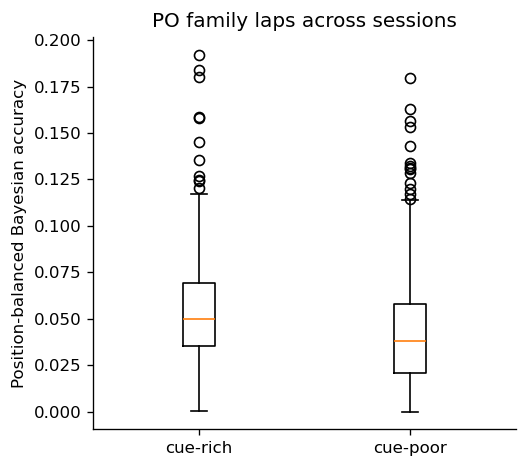

In [40]:
plot_df = lap_zone_df.dropna(subset=["position_balanced_accuracy"])

fig, ax = plt.subplots(figsize=(4.5, 4))

zone_order = ["rich", "poor"]
data = [
    plot_df.loc[plot_df["cue_zone"] == zone, "position_balanced_accuracy"].to_numpy()
    for zone in zone_order
]

ax.boxplot(
    data,
    tick_labels=["cue-rich", "cue-poor"],
    showfliers=True,
)
ax.set_ylabel("Position-balanced Bayesian accuracy")
ax.set_title("PO family laps across sessions")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()


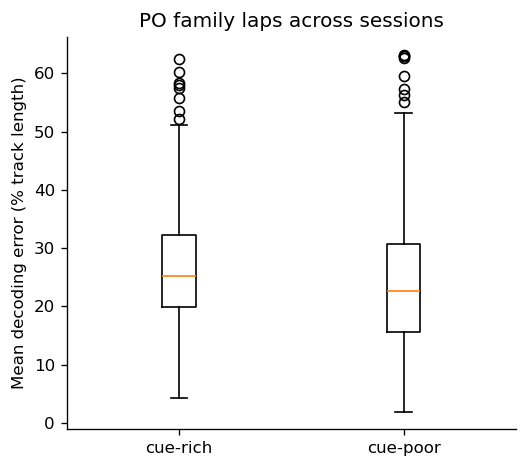

In [41]:
fig, ax = plt.subplots(figsize=(4.5, 4))
data = [
    plot_df.loc[plot_df["cue_zone"] == zone, "mean_error_percent"].to_numpy()
    for zone in zone_order
]

ax.boxplot(
    data,
    tick_labels=["cue-rich", "cue-poor"],
    showfliers=True,
)
ax.set_ylabel("Mean decoding error (% track length)")
ax.set_title("PO family laps across sessions")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()


In [42]:
from scipy.stats import wilcoxon
metric = "position_balanced_accuracy"
paired = (
    lap_zone_df
    .pivot_table(
        index=["session_id", "condition_name", "direction", "trial_index"],
        columns="cue_zone",
        values=metric,
        aggfunc="mean",
    )
    .dropna(subset=["rich", "poor"])
)

paired["rich_minus_poor"] = paired["rich"] - paired["poor"]

session_diff = (
    paired
    .groupby("session_id")["rich_minus_poor"]
    .mean()
)

stat, p = wilcoxon(session_diff)

print(f"n sessions = {len(session_diff)}")
print(f"mean session difference = {session_diff.mean():.4f}")
print(f"Wilcoxon signed-rank p = {p:.4g}")


n sessions = 18
mean session difference = 0.0114
Wilcoxon signed-rank p = 0.000145


In [43]:
import statsmodels.formula.api as smf

df = lap_zone_df.dropna(subset=["position_balanced_accuracy"]).copy()
df = df[df["cue_zone"].isin(["rich", "poor"])]

df["cue_zone"] = pd.Categorical(
    df["cue_zone"],
    categories=["poor", "rich"],
)

model = smf.mixedlm(
    "position_balanced_accuracy ~ cue_zone",
    data=df,
    groups=df["session_id"],
)

fit = model.fit()
print(fit.summary())

                 Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: position_balanced_accuracy
No. Observations: 1014    Method:             REML                      
No. Groups:       18      Scale:              0.0008                    
Min. group size:  18      Log-Likelihood:     2176.9018                 
Max. group size:  160     Converged:          Yes                       
Mean group size:  56.3                                                  
--------------------------------------------------------------------------
                       Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
--------------------------------------------------------------------------
Intercept              0.044      0.003   17.284   0.000    0.039    0.049
cue_zone[T.rich]       0.012      0.002    6.655   0.000    0.008    0.015
Group Var              0.000      0.001                                   



c:\Users\tadse\miniconda3\envs\odors\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [44]:
model = smf.mixedlm(
    "mean_error_percent ~ cue_zone",
    data=df,
    groups=df["session_id"],
)
fit = model.fit()
print(fit.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_error_percent
No. Observations: 1014    Method:             REML              
No. Groups:       18      Scale:              106.7829          
Min. group size:  18      Log-Likelihood:     -3814.7809        
Max. group size:  160     Converged:          Yes               
Mean group size:  56.3                                          
-----------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept         23.638     0.683  34.622  0.000  22.299  24.976
cue_zone[T.rich]   2.675     0.649   4.122  0.000   1.403   3.947
Group Var          4.165     0.232                               

